# Optimotion PoC Simulation Notebook
This notebook demonstrates the full optimization process for a two-joint robotic arm using forward kinematics and gradient descent.  
It is referenced in TP02 Appendix B and supports the Methodology section with visual outputs.

## Imports & Setup
These cells ensure modules from `/src` are importable and that all visualizations are saved to the root-level `/outputs/` directory.

### Libraries

In [1]:
import numpy as np
import os
import sys

#### Ensure /src is importable

In [2]:
sys.path.append(os.path.abspath(".."))

#### Set the true top-level /outputs path

In [3]:
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
output_dir = os.path.join(project_root, "outputs")
os.makedirs(output_dir, exist_ok=True)

In [4]:
print("✅ Output path set to:", output_dir)

✅ Output path set to: c:\Users\MissV\OneDrive\Documents\Education\CityU\2025SpringQ6\DS623\TP\DS623-Optimotion\outputs


### Core computation imports

In [5]:
from src.robotic_arm import forward_kinematics
from src.optimizer import compute_cost, compute_gradients, optimize_arm

## To explain **gradient descent for a robotic arm** in **layman's terms**, let's use an analogy and then walk through the process with simple math.

---

## 🧠 **Imagine This Situation**

You're **controlling a robotic arm** to point at a fly on the wall. But your eyes are closed. You **don’t know the perfect angles** for the arm’s joints, so you **guess**, then feel around to see how far you are from the fly.

Over time, you **adjust a little** left or right based on whether the arm gets closer or farther from the fly. You **repeat this slowly** until you're as close to the fly as possible. That’s **gradient descent**.

---

## 💡 Key Terms

* **Joint Angles**: θ₁ and θ₂ (how much each joint is bent).
* **End-Effector**: The tip of the arm (the fingertip).
* **Target Point**: Where we want the end-effector to reach.
* **Cost Function**: Measures how far the end-effector is from the target.
* **Gradient**: Tells us in which direction (increase/decrease angle) the cost is going up or down.
* **Learning Rate**: How big of a step we take in each update.

---

## 🔧 Step-by-Step Breakdown

### 1. **Forward Kinematics: Where is my arm tip right now?**

From the current angles θ₁ and θ₂, we find the **(x, y)** position of the end-effector.

$$
x = l_1 \cos(\theta_1) + l_2 \cos(\theta_1 + \theta_2)
$$

$$
y = l_1 \sin(\theta_1) + l_2 \sin(\theta_1 + \theta_2)
$$

This math **adds up the positions of each segment**, considering the rotation at each joint.

---

### 2. **Compute Cost: How far am I from the goal?**

$$
\text{Cost} = \sqrt{(x - x_\text{target})^2 + (y - y_\text{target})^2}
$$

This is just the straight-line distance between where the robotic arm’s tip is and where it needs to go.

---

### 3. **Compute Gradient: Which direction should I move the angles?**

We **slightly nudge** θ₁ and θ₂ a bit (like poking them):

```python
grad_theta1 ≈ (cost after nudging θ₁ - current cost) / epsilon
grad_theta2 ≈ (cost after nudging θ₂ - current cost) / epsilon
```

This is called **numerical gradient using finite differences**.

Imagine feeling around to see if bending a joint makes you closer to or farther from the fly. If it helps, great! You note that direction.

---

### 4. **Update Angles: Move towards lower cost**

Now we use the gradients to update the angles:

$$
\theta_1 = \theta_1 - \text{learning\_rate} \times \text{grad}_1
$$

$$
\theta_2 = \theta_2 - \text{learning\_rate} \times \text{grad}_2
$$

If the gradient is positive, this means increasing the angle increased the cost — so we subtract. If negative, we’re on the right track and keep going.

This is like adjusting your arm a little based on which direction helps.

---

### 5. **Repeat Until Done**

Do this many times (say 50 or 100 times). Each time:

* Compute current position
* Measure distance to target
* Nudge angles to find gradients
* Update angles to reduce cost

Eventually, the arm should **point almost exactly at the target**.

---

## 📈 Summary in Plain English

* The robotic arm wants to touch a point.
* It starts by guessing where to point.
* It measures how far the guess is.
* It nudges its joints to see which direction gets it closer.
* It adjusts the joints a bit at a time.
* After many tries, it gets super close.

---

### Acknowledgments
### OpenAI. (2025). *ChatGPT for formatting* [Large language model]. https://openai.com/chatgpt

---

### Plot utilities (import as functions or call via CLI as needed)

In [6]:
from src.visualizations.cost_convergence_plot import plot_cost_convergence
from src.visualizations.pose_comparison_plot import plot_pose_comparison

## Define Run Simulation

In [ ]:
def run_simulation():
    # Initial angles
    theta1_init = np.radians(20)
    theta2_init = np.radians(10)
    # Target position
    target_x, target_y = 1.2, 1.3

    # Run optimization
    theta1_final, theta2_final, history = optimize_arm(
        theta1_init,
        theta2_init,
        target_x,
        target_y,
        learning_rate=0.1,
        iterations=50
    )
    
    # Extract costs for plotting
    costs = [entry[2] for entry in history]

    plot_cost_convergence(
        costs, 
        title="Cost Convergence (PoC Run)",
        output_dir=output_dir, 
        filename="poc_cost_convergence.png"
    )

    # Plot arm pose comparison (initial vs. optimized)
    plot_pose_comparison(
        theta1_init, theta2_init,
        theta1_final, theta2_final,
        title="Pose Comparison: Initial vs. Optimized (PoC Run)",
        output_dir=output_dir,
        filename="poc_pose_comparison.png"
    )

    # Output summary
    print(f"✅ Final Angles: θ1 = {np.degrees(theta1_final):.2f}°, θ2 = {np.degrees(theta2_final):.2f}°")
    print(f"✅ Final Cost: {costs[-1]:.4f}")

## Run Gradient Descent Optimization
This cell performs 50 iterations of gradient descent using numerical gradient approximation.  
We store the history of θ₁, θ₂, and cost per iteration.

Iteration 1: Cost = 0.7594
Iteration 11: Cost = 0.2074
Iteration 21: Cost = 0.2090
Iteration 31: Cost = 0.2100
Iteration 41: Cost = 0.2221
Iteration 50: Cost = 0.1451
✅ Cost convergence plot saved to: c:\Users\MissV\OneDrive\Documents\Education\CityU\2025SpringQ6\DS623\TP\DS623-Optimotion\outputs\poc_cost_convergence.png


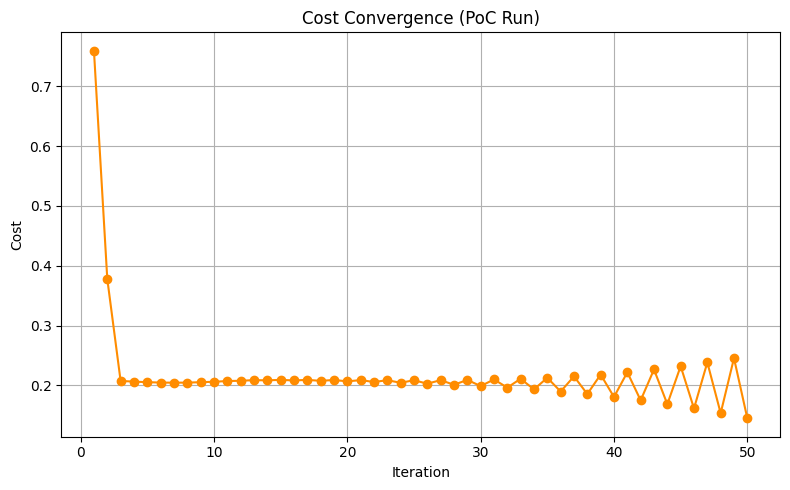

✅ Pose comparison plot saved to: c:\Users\MissV\OneDrive\Documents\Education\CityU\2025SpringQ6\DS623\TP\DS623-Optimotion\outputs\poc_pose_comparison.png


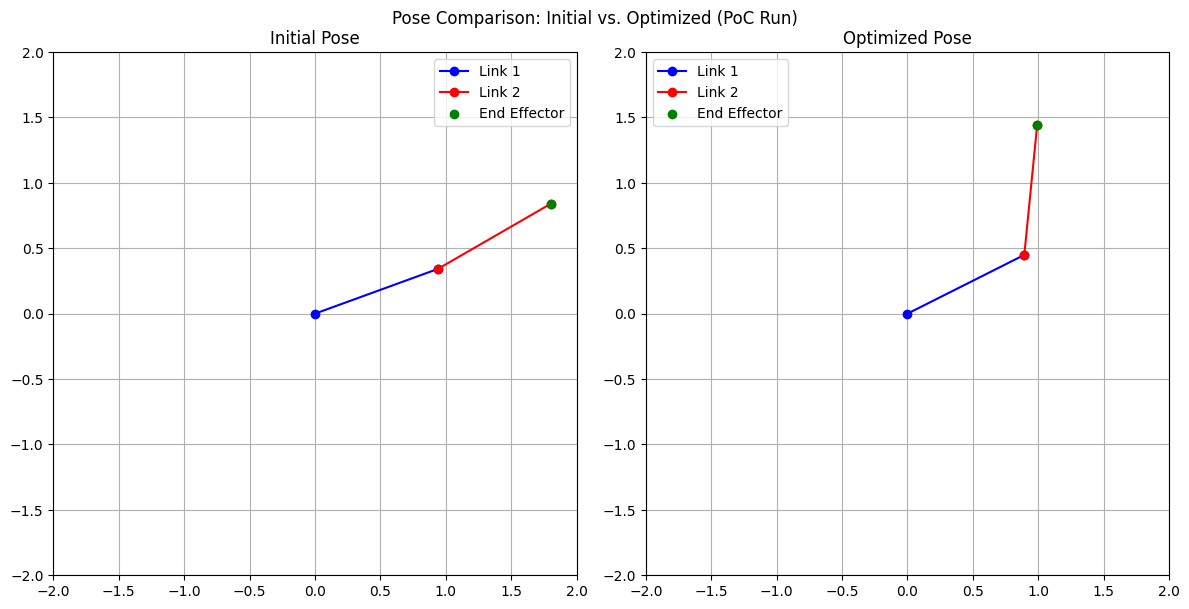

✅ Final Angles: θ1 = 26.70°, θ2 = 57.65°
✅ Final Cost: 0.1451


In [8]:
if __name__ == "__main__":
    run_simulation()

## Acknowledgments
OpenAI. (2025). *ChatGPT’s assistance with mathematical modeling and code generation for DS623 Optimotion project* [Large language model]. https://openai.com/chatgpt